# QUIZ PBA

### Nama: Viera Tito Virgiawan
### NRP: 5026221096

In [13]:
# Install necessary libraries (if not already installed)
%pip install beautifulsoup4 requests pandas

Note: you may need to restart the kernel to use updated packages.


In [27]:
from pathlib import Path
import requests
from bs4 import BeautifulSoup
import pandas as pd

## Scrape News URL

In [ ]:
# Articles defined inline — add or remove entries here
ARTICLES = [
    {
        "url": "https://apnews.com/article/climate-electric-vehicles-gasoline-emissions-fossil-fuels-4a37b8f7dab121f5029fd06bed7123c7",
        "title": "Study finds EVs quickly overcome their energy-intensive build to be cleaner than gas cars"
    },
    {
        "url": "https://greatlakesecho.org/2026/02/14/why-michigans-rural-residents-are-reluctant-to-drive-electric-vehicles/",
        "title": "Why Michigan’s rural residents are reluctant to drive electric vehicles"
    },
    {
        "url": "https://www.ladbible.com/news/technology/electric-cars-environmental-benefit-electricity-306719-20260211",
        "title": "Scientists issue warning about how good electric cars really are for environment"
    },
    {
        "url": "https://www.bbc.com/news/articles/c30741j351go",
        "title": "How the rise of green tech is feeding another environmental crisis"
    },
    {
        "url": "https://www.bbc.com/news/articles/c0k36v50zvro",
        "title": "Race to mine metals for EV batteries threatens marine paradise"
    },
]

def scrape_content(entry):
    url = entry["url"]
    fallback_title = entry["title"]
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')
            scraped_title = soup.find('title')
            title = scraped_title.text if scraped_title else fallback_title
            paragraphs = soup.find_all('p')
            content = "\n".join([p.get_text(strip=True) for p in paragraphs])
            return {"url": url, "title": title, "content": content}
        else:
            return {"url": url, "title": fallback_title, "content": None,
                    "error": f"HTTP {response.status_code}"}
    except Exception as e:
        return {"url": url, "title": fallback_title, "content": None, "error": str(e)}

df = pd.DataFrame([scrape_content(a) for a in ARTICLES])
print(f"Scraped {len(df)} articles")
df.head()

In [ ]:
empty_content_count = df['content'].isna().sum()
print(f"Number of entries with empty content: {empty_content_count}")
if empty_content_count > 0:
    print("Articles with missing content:")
    print(df[df['content'].isna()][['url', 'title', 'error']])

## Preprocessing

In [ ]:
%pip install -q spacy
!python -m spacy download en_core_web_sm -q

In [ ]:
%pip install -q nltk

In [30]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /home/ergia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/ergia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text.strip()

df_scraped = df.copy()

# Step 1: surface-level cleaning → plain string (used by NER and Sentiment)
df_scraped['clean_content'] = df_scraped['content'].apply(preprocess_text)

# Step 2: tokenize (lowercased)
df_scraped['tokens'] = df_scraped['clean_content'].apply(
    lambda t: word_tokenize(t.lower()) if t else []
)

# Step 3: remove stopwords and non-alpha tokens
df_scraped['tokens_no_stopwords'] = df_scraped['tokens'].apply(
    lambda toks: [t for t in toks if t.isalpha() and t not in STOPWORDS]
)

# Step 4: join back to string (used by TF-IDF)
df_scraped['clean_tokens_str'] = df_scraped['tokens_no_stopwords'].apply(
    lambda toks: ' '.join(toks)
)

print(f"Preprocessed {len(df_scraped)} articles")
df_scraped[['url', 'clean_content', 'tokens', 'tokens_no_stopwords']].head()

In [32]:
# Compare text length at each preprocessing stage
df_scraped['original_len'] = df_scraped['content'].apply(lambda x: len(str(x)))
df_scraped['clean_len'] = df_scraped['clean_content'].apply(len)
df_scraped['token_count'] = df_scraped['tokens'].apply(len)
df_scraped['token_count_no_sw'] = df_scraped['tokens_no_stopwords'].apply(len)

print(df_scraped[['url', 'original_len', 'clean_len', 'token_count', 'token_count_no_sw']].to_string(index=False))

                                                                                                                  url  original_len  clean_len  token_count  token_count_no_sw
https://apnews.com/article/climate-electric-vehicles-gasoline-emissions-fossil-fuels-4a37b8f7dab121f5029fd06bed7123c7          7020       6958         1261                646
        https://greatlakesecho.org/2026/02/14/why-michigans-rural-residents-are-reluctant-to-drive-electric-vehicles/          5617       5476          926                523
             https://www.ladbible.com/news/technology/electric-cars-environmental-benefit-electricity-306719-20260211          3843       3842          726                356
                                                                       https://www.bbc.com/news/articles/c30741j351go         13378      13370         2587               1185
                                                                       https://www.bbc.com/news/articles/c0k36v50zvro        

## Named Entity Recognition (NER)

In [33]:
import spacy
from spacy.tokens import Doc, Span
from spacy import displacy

nlp = spacy.load("en_core_web_sm")

# Run NER on each article's cleaned content (truncate to 5000 chars to keep it fast)
def run_ner(text, max_chars=5000):
    return nlp(text[:max_chars])

df_scraped['spacy_doc'] = df_scraped['clean_content'].apply(run_ner)

print("NER complete. Entity counts per article:")
for _, row in df_scraped.iterrows():
    n = len(row['spacy_doc'].ents)
    short_url = row['url'].split('//')[-1][:60]
    print(f"  {short_url} → {n} entities")

NER complete. Entity counts per article:
  apnews.com/article/climate-electric-vehicles-gasoline-emissi → 82 entities
  greatlakesecho.org/2026/02/14/why-michigans-rural-residents- → 52 entities
  www.ladbible.com/news/technology/electric-cars-environmental → 28 entities
  www.bbc.com/news/articles/c30741j351go → 61 entities
  www.bbc.com/news/articles/c0k36v50zvro → 58 entities


In [34]:
# Aggregate all entities into a summary DataFrame
entity_records = []
for _, row in df_scraped.iterrows():
    for ent in row['spacy_doc'].ents:
        entity_records.append({
            'url': row['url'],
            'entity': ent.text,
            'label': ent.label_,
            'description': spacy.explain(ent.label_)
        })

df_entities = pd.DataFrame(entity_records)

print(f"Total entities found: {len(df_entities)}")
print("\nTop entity types:")
print(df_entities['label'].value_counts().head(10))
df_entities.head(20)

Total entities found: 281

Top entity types:
label
ORG         76
GPE         49
DATE        47
PERSON      37
CARDINAL    21
PERCENT     14
LOC          9
QUANTITY     8
NORP         8
MONEY        3
Name: count, dtype: int64


,url,entity,label,description
0,https://apnews.com/article/climate-electric-ve...,2026,DATE,Absolute or relative dates or periods
1,https://apnews.com/article/climate-electric-ve...,The Associated Press,ORG,"Companies, agencies, institutions, etc."
2,https://apnews.com/article/climate-electric-ve...,2026,DATE,Absolute or relative dates or periods
3,https://apnews.com/article/climate-electric-ve...,The Associated Press,ORG,"Companies, agencies, institutions, etc."
4,https://apnews.com/article/climate-electric-ve...,"May 22, 2025",DATE,Absolute or relative dates or periods
5,https://apnews.com/article/climate-electric-ve...,the City of Commerce,GPE,"Countries, cities, states"
6,https://apnews.com/article/climate-electric-ve...,Calif.,GPE,"Countries, cities, states"
7,https://apnews.com/article/climate-electric-ve...,"AP Photo/Jae C. Hong, File) Electric",ORG,"Companies, agencies, institutions, etc."
8,https://apnews.com/article/climate-electric-ve...,Electrify America,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
9,https://apnews.com/article/climate-electric-ve...,Arcadia,GPE,"Countries, cities, states"


In [35]:
# Visualize NER for each article using displacy
for _, row in df_scraped.iterrows():
    short_url = row['url'].split('//')[-1][:80]
    print(f"\n--- {short_url} ---")
    displacy.render(row['spacy_doc'], style="ent", jupyter=True)


--- apnews.com/article/climate-electric-vehicles-gasoline-emissions-fossil-fuels-4a3 ---



--- greatlakesecho.org/2026/02/14/why-michigans-rural-residents-are-reluctant-to-dri ---



--- www.ladbible.com/news/technology/electric-cars-environmental-benefit-electricity ---



--- www.bbc.com/news/articles/c30741j351go ---



--- www.bbc.com/news/articles/c0k36v50zvro ---


## Sentiment Analysis (TextBlob)

In [ ]:
%pip install -q textblob

In [36]:
from textblob import TextBlob

def get_sentiment(text):
    if not text:
        return None, None, "unknown"
    blob = TextBlob(text)
    polarity = round(blob.sentiment.polarity, 4)       # -1 (negative) to +1 (positive)
    subjectivity = round(blob.sentiment.subjectivity, 4)  # 0 (objective) to 1 (subjective)
    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"
    return polarity, subjectivity, label

df_scraped[['polarity', 'subjectivity', 'sentiment']] = df_scraped['clean_content'].apply(
    lambda t: pd.Series(get_sentiment(t))
)

print(df_scraped[['url', 'polarity', 'subjectivity', 'sentiment']].to_string(index=False))

                                                                                                                  url  polarity  subjectivity sentiment
https://apnews.com/article/climate-electric-vehicles-gasoline-emissions-fossil-fuels-4a37b8f7dab121f5029fd06bed7123c7    0.1201        0.3993  positive
        https://greatlakesecho.org/2026/02/14/why-michigans-rural-residents-are-reluctant-to-drive-electric-vehicles/    0.1195        0.3408  positive
             https://www.ladbible.com/news/technology/electric-cars-environmental-benefit-electricity-306719-20260211    0.2441        0.4087  positive
                                                                       https://www.bbc.com/news/articles/c30741j351go    0.0859        0.4306  positive
                                                                       https://www.bbc.com/news/articles/c0k36v50zvro    0.0970        0.3792  positive


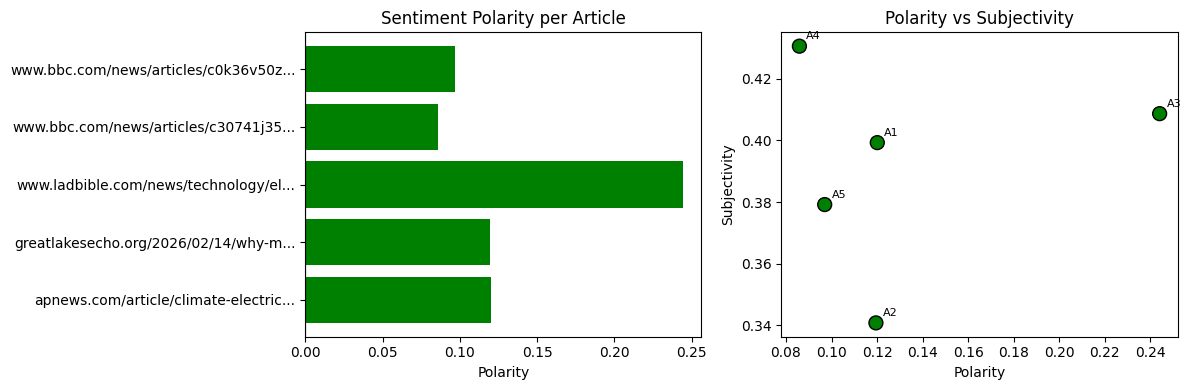


Article index mapping:
  A1: https://apnews.com/article/climate-electric-vehicles-gasoline-emissions-fossil-fuels-4a37b8f7dab121f5029fd06bed7123c7
  A2: https://greatlakesecho.org/2026/02/14/why-michigans-rural-residents-are-reluctant-to-drive-electric-vehicles/
  A3: https://www.ladbible.com/news/technology/electric-cars-environmental-benefit-electricity-306719-20260211
  A4: https://www.bbc.com/news/articles/c30741j351go
  A5: https://www.bbc.com/news/articles/c0k36v50zvro


In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: polarity per article
short_labels = [url.split('//')[-1][:35] + '...' for url in df_scraped['url']]
colors = ['green' if s == 'positive' else 'red' if s == 'negative' else 'gray'
          for s in df_scraped['sentiment']]

axes[0].barh(short_labels, df_scraped['polarity'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Polarity')
axes[0].set_title('Sentiment Polarity per Article')

# Scatter: polarity vs subjectivity
axes[1].scatter(df_scraped['polarity'], df_scraped['subjectivity'], c=colors, s=100, edgecolors='black')
for i, row in df_scraped.iterrows():
    axes[1].annotate(f"A{i+1}", (row['polarity'], row['subjectivity']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Polarity')
axes[1].set_ylabel('Subjectivity')
axes[1].set_title('Polarity vs Subjectivity')

plt.tight_layout()
plt.show()

# Legend
print("\nArticle index mapping:")
for i, url in enumerate(df_scraped['url']):
    print(f"  A{i+1}: {url}")

## TF-IDF Analysis

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use pre-tokenized, stopword-removed text so the vectorizer works on clean terms
corpus = df_scraped['clean_tokens_str'].fillna("").tolist()

vectorizer = TfidfVectorizer(
    max_features=50,
    ngram_range=(1, 2),   # unigrams and bigrams
    min_df=1
    # stop_words removed: stopwords already stripped during preprocessing
)

tfidf_matrix = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=[f"A{i+1}" for i in range(len(corpus))]
)

print(f"TF-IDF matrix shape: {df_tfidf.shape}  (articles × terms)")
df_tfidf

TF-IDF matrix shape: (5, 50)  (articles × terms)


,also,ap,atacama,batteries,battery,bbc,change,charging,chile,climate,...,rural,said,say,says,study,university,vehicle,vehicles,water,world
A1,0.087821,0.414678,0.00000,0.103832,0.123429,0.000000,0.103832,0.185866,0.000000,0.175641,...,0.000000,0.263462,0.000000,0.025958,0.153686,0.109776,0.233622,0.277715,0.000000,0.030857
A2,0.118859,0.000000,0.00000,0.140530,0.167052,0.000000,0.000000,0.482990,0.000000,0.023772,...,0.548766,0.261490,0.140530,0.000000,0.142631,0.095087,0.196741,0.133642,0.000000,0.000000
A3,0.045769,0.000000,0.00000,0.000000,0.000000,0.000000,0.054114,0.000000,0.000000,0.091539,...,0.000000,0.228847,0.162343,0.108228,0.091539,0.045769,0.054114,0.321637,0.000000,0.000000
A4,0.047334,0.000000,0.24834,0.027982,0.000000,0.080144,0.111928,0.000000,0.347676,0.094668,...,0.000000,0.059168,0.069955,0.293812,0.035501,0.035501,0.000000,0.000000,0.460826,0.083158
A5,0.027636,0.000000,0.00000,0.032674,0.038841,0.467915,0.032674,0.000000,0.000000,0.082907,...,0.000000,0.082907,0.065349,0.065349,0.055272,0.027636,0.032674,0.000000,0.093583,0.116523


In [39]:
# Top-N most important terms per article
TOP_N = 10

print(f"Top {TOP_N} TF-IDF terms per article:\n")
for article in df_tfidf.index:
    top_terms = (
        df_tfidf.loc[article]
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    terms_str = ", ".join([f"{t} ({v:.3f})" for t, v in top_terms.items() if v > 0])
    url = df_scraped.iloc[int(article[1:])-1]['url']
    print(f"{article}: {url.split('//')[-1][:50]}")
    print(f"      {terms_str}\n")

Top 10 TF-IDF terms per article:

A1: apnews.com/article/climate-electric-vehicles-gasol
      evs (0.446), ap (0.415), vehicles (0.278), said (0.263), electric (0.242), vehicle (0.234), ev (0.216), charging (0.186), electric vehicles (0.185), climate (0.176)

A2: greatlakesecho.org/2026/02/14/why-michigans-rural-
      rural (0.549), charging (0.483), said (0.261), electric (0.238), vehicle (0.197), electric vehicle (0.169), found (0.169), battery (0.167), ev (0.167), study (0.143)

A3: www.ladbible.com/news/technology/electric-cars-env
      grid (0.465), evs (0.387), power (0.325), vehicles (0.322), electric (0.320), electric vehicles (0.257), said (0.229), news (0.162), say (0.162), government (0.162)

A4: www.bbc.com/news/articles/c30741j351go
      water (0.461), lithium (0.399), chile (0.348), says (0.294), mining (0.294), companies (0.281), atacama (0.248), communities (0.150), mining companies (0.140), new (0.116)

A5: www.bbc.com/news/articles/c0k36v50zvro
      nickel (0.580

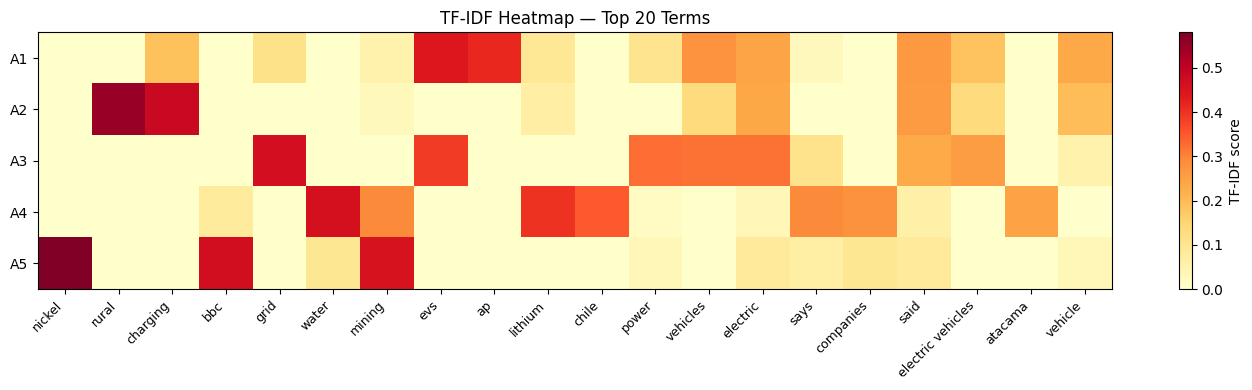

In [40]:
# Heatmap: TF-IDF scores across articles
import matplotlib.pyplot as plt
import numpy as np

# Pick top-20 terms by max score across all articles for a cleaner heatmap
top20_terms = df_tfidf.max(axis=0).sort_values(ascending=False).head(20).index
df_heat = df_tfidf[top20_terms]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(df_heat.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(top20_terms)))
ax.set_xticklabels(top20_terms, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(df_heat.index)))
ax.set_yticklabels(df_heat.index)
ax.set_title('TF-IDF Heatmap — Top 20 Terms')

plt.colorbar(im, ax=ax, label='TF-IDF score')
plt.tight_layout()
plt.show()